# Phần 2: Ứng Dụng Data Fitting Vào Dữ Liệu Thực Tế

Notebook nay trinh bay pipeline data fitting hoan chinh: tien xu ly du lieu thuc te, xay dung va so sanh OLS, Feature-Selected OLS, Ridge, Lasso, Kernel Ridge va Bayesian Linear Regression tren tap test doc lap, kem phan tich residual diagnostics.

---

## 1. Mô tả Bộ Dữ Liệu Weather in Australia

Chúng ta sử dụng bộ dữ liệu [weatherAUS.csv](file:///d:/Applied%20Statistics/project_2/part2/data/weatherAUS.csv) ghi nhận các thông số thời tiết hàng ngày tại nhiều trạm khí tượng ở Úc.

### 1.1. Các Ràng Buộc & Tiêu Chí Thiết Kế Bộ Dữ Liệu
1. **Dữ liệu thực tế:** Không sử dụng bộ dữ liệu đồ chơi (như Iris, Boston Housing).
2. **Tỷ lệ khuyết thiếu (Missing Rate):** Bộ dữ liệu gốc có nhiều cột bị khuyết dữ liệu lớn hơn 5% (ví dụ: Evaporation ~43%, Sunshine ~48%, Cloud9am ~38%).
3. **Biến mục tiêu liên tục:** Chọn `MaxTemp` (Nhiệt độ lớn nhất trong ngày) làm biến mục tiêu hồi quy.
4. **Rò rỉ thông tin (Target Leakage):** Loại bỏ các cột liên quan đến tương lai như `RISK_MM` (lượng mưa ngày tiếp theo) và `RainTomorrow` để mô hình phản ánh đúng thực tế dự báo.
5. **Quy mô:** $n = 10,000$ mẫu ngẫu nhiên (để đảm bảo hiệu suất tính toán cho Coordinate Descent), số lượng đặc trưng sau khi mã hóa one-hot là $p = 120$.

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập thư mục gốc để import các module tự thiết kế
sys.path.append(os.path.dirname(os.getcwd()))

from part1.ols_implementation import ols_fit, coef_inference, model_metrics
from part1.ridge_lasso import ridge_fit, lasso_fit, vif
from part1.residual_analysis import residual_plots
from part2.data_pipeline import DataPipeline

import warnings
warnings.filterwarnings('ignore')

## 2. Tiền Xử Lý Dữ Liệu & Ngăn Ngừa Rò Rỉ Thông Tin (Data Leakage)

Để đảm bảo tính trung thực và khả năng tổng quát hóa của mô hình hồi quy:
1. **Phân chia Train/Test Split (80/20):** Chia dữ liệu trước khi thực hiện bất kỳ phép tiền xử lý hay chuẩn hóa nào.
2. **Stateful Pipeline (Fit/Transform):** 
   * Học các tham số điền khuyết (median của các cột số, mode của các cột phân loại) trên tập Train và áp dụng sang tập Test.
   * Học các tham số Z-score normalization (mean, std) trên tập Train và áp dụng công thức chuẩn hóa $X_{scaled} = \frac{X - \mu_{train}}{\sigma_{train}}$ cho cả Train và Test.
3. **Mã hóa biến phân loại (Categorical Encoding):** Sử dụng One-hot encoding cho các biến phân loại (`Location`, `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`, `Month`). Để tránh bẫy đa cộng tuyến hoàn hảo (Dummy Variable Trap), ta lược bỏ cột phân loại đầu tiên cho mỗi nhóm đặc trưng.

In [8]:
from part2.model_comparison import DataPipeline

# Khởi động pipeline tải dữ liệu
data_path = "data/weatherAUS.csv"
df = pd.read_csv(data_path)
df['Month'] = pd.to_datetime(df['Date']).dt.month.astype(str)
target_col = 'MaxTemp'
df = df.dropna(subset=[target_col]).copy()
df.drop(columns=[col for col in ['RISK_MM', 'RainTomorrow', 'Date'] if col in df.columns], inplace=True)

# Lọc các cột số và phân loại
num_cols = ['MinTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 
            'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 
            'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month']

num_cols = [col for col in num_cols if col in df.columns]
cat_cols = [col for col in cat_cols if col in df.columns]

# Lấy mẫu 10,000 dòng
df_sampled = df.sample(n=min(10000, len(df)), random_state=42).copy()

# Phân chia tập dữ liệu ngẫu nhiên
n_samples = len(df_sampled)
indices = np.arange(n_samples)
np.random.seed(42)
np.random.shuffle(indices)
split_point = int(n_samples * 0.8)

train_df = df_sampled.iloc[indices[:split_point]].copy()
test_df = df_sampled.iloc[indices[split_point:]].copy()

y_train = train_df[target_col].to_numpy()
y_test = test_df[target_col].to_numpy()

# Chạy pipeline tiền xử lý
pipeline = DataPipeline(strategy='median')
pipeline.fit(train_df, num_cols, cat_cols)

X_train, column_names = pipeline.transform(train_df)
X_test, _ = pipeline.transform(test_df)

print(f"Kích thước ma trận Train (sau tiền xử lý): {X_train.shape}")
print(f"Kích thước ma trận Test  (sau tiền xử lý): {X_test.shape}")

Kích thước ma trận Train (sau tiền xử lý): (8000, 121)
Kích thước ma trận Test  (sau tiền xử lý): (2000, 121)


# 3. Phần nâng cao

### 3.1. Kernel Ridge regression
##### 3.1.1. Cơ sở lý thuyết
Kernel Ridge Regression kết hợp **hồi quy Ridge** với **kernel trick**. Thay vì khớp mô hình tuyến tính trực tiếp trong không gian đặc trưng ban đầu, phương pháp này khớp mô hình có điều chuẩn trong một không gian đặc trưng ngầm định.

Với dữ liệu huấn luyện:

$$
X = \{x_1, x_2, \dots, x_n\}, \qquad y \in \mathbb{R}^n
$$

Kernel Ridge xây dựng ma trận Gram:

$$
K_{ij} = k(x_i, x_j)
$$

trong đó $k(\cdot, \cdot)$ là hàm kernel.

**Linear kernel**

$$
k(x_i, x_j) = x_i^T x_j
$$

**Polynomial kernel**

$$
k(x_i, x_j) = (x_i^T x_j + c)^d
$$

**RBF kernel**

$$
k(x_i, x_j)
=
\exp\left(
-\frac{\|x_i - x_j\|^2}{2\sigma^2}
\right)
$$

Mô hình giải hệ:

$$
\alpha = (K + \lambda I)^{-1}y
$$

trong đó:

- $K$ là ma trận kernel kích thước $R^{2 \times 2}$,
- $\lambda$ là hệ số điều chuẩn Ridge,
- $I$ là ma trận đơn vị,
- $\alpha$ là vector hệ số ở dạng đối ngẫu.

Với điểm kiểm tra mới $x_*$, dự báo là:

$$
\hat{y}_* = k(x_*, X)^T \alpha
$$

Với nhiều điểm kiểm tra:

$$
\hat{y}_{test} = K_{test}\alpha
$$


### 3.1.2. Áp dụng bằng python

In [1]:
class KernelRidgeRegression:
    """
    Exact Kernel Ridge Regression from scratch.

    Training:
        alpha = (K + lambda I)^(-1) y

    Prediction:
        y_hat = K_test @ alpha

    Notes:
        This model builds a full n x n Gram matrix, so use a training subset
        for large datasets.
    """

    def __init__(self, kernel="rbf", lambda_reg=1.0, sigma=1.0, degree=2, coef0=1.0):
        self.kernel = kernel
        self.lambda_reg = lambda_reg
        self.sigma = sigma
        self.degree = degree
        self.coef0 = coef0
        self.X_train = None
        self.alpha = None

    def _linear_kernel(self, X1, X2):
        return np.matmul(X1, np.transpose(X2))

    def _polynomial_kernel(self, X1, X2):
        return (np.matmul(X1, np.transpose(X2)) + self.coef0) ** self.degree

    def _rbf_kernel(self, X1, X2):
        X1_sq = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
        X2_sq = np.sum(X2 ** 2, axis=1).reshape(1, -1)
        dist_sq = X1_sq + X2_sq - 2.0 * (X1 @ X2.T)
        dist_sq = np.maximum(dist_sq, 0.0)
        return np.exp(-dist_sq / (2.0 * self.sigma ** 2))

    def _compute_kernel(self, X1, X2):
        X1 = np.asarray(X1, dtype=np.float64)
        X2 = np.asarray(X2, dtype=np.float64)

        if self.kernel == "linear":
            return self._linear_kernel(X1, X2)
        if self.kernel == "polynomial":
            return self._polynomial_kernel(X1, X2)
        if self.kernel == "rbf":
            return self._rbf_kernel(X1, X2)

        raise ValueError("kernel must be one of: 'linear', 'polynomial', 'rbf'")

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).ravel()

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.X_train = X
        n_samples = X.shape[0]

        print(f"[Exact KRR] Building Gram matrix: {n_samples} x {n_samples}")
        K = self._compute_kernel(X, X)

        A = K + self.lambda_reg * np.eye(n_samples)

        print("[Exact KRR] Solving (K + lambda I) alpha = y")
        self.alpha = np.linalg.solve(A, y)

        return self

    def predict(self, X, batch_size=5000):
        if self.alpha is None:
            raise ValueError("Model has not been fitted yet.")

        X = np.asarray(X, dtype=np.float64)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        preds = []

        for start in range(0, X.shape[0], batch_size):
            end = start + batch_size
            X_batch = X[start:end]
            K_batch = self._compute_kernel(X_batch, self.X_train)
            preds.append(K_batch @ self.alpha)

        return np.concatenate(preds)


### 3.2. Bayesian Linear Regression 
##### 3.2.1. Cơ sở lý thuyết 
Bayesian Linear Regression xem các hệ số hồi quy là biến ngẫu nhiên thay vì hằng số cố định.

Mô hình giả định likelihood Gaussian:

$$
y \mid X, \beta \sim \mathcal{N}(X\beta, \sigma^2 I)
$$

Prior của hệ số hồi quy cũng là Gaussian:

$$
\beta \sim \mathcal{N}(0, \alpha^{-1}I)
$$

Vì prior và likelihood đều là Gaussian, posterior cũng có dạng Gaussian:

$$
\beta \mid X, y \sim \mathcal{N}(m_n, S_n)
$$

Ma trận hiệp phương sai hậu nghiệm:

$$
S_n =
\left(
\alpha I + \frac{1}{\sigma^2}X^T X
\right)^{-1}
$$

Kỳ vọng hậu nghiệm:

$$
m_n =
S_n
\left(
\frac{1}{\sigma^2}X^T y
\right)
$$

Dự báo cho dữ liệu mới:

$$
\hat{y} = X_{new}m_n
$$

Phương sai dự báo:

$$
\operatorname{Var}(y_* \mid x_*, X, y)
=
\sigma^2 + x_*^T S_n x_*
$$

Độ lệch chuẩn dự báo:

$$
\operatorname{Std}(y_*)
=
\sqrt{
\sigma^2 + x_*^T S_n x_*
}
$$


In [9]:
class BayesianLinearRegression:
    """
    Bayesian Linear Regression with Gaussian prior and Gaussian likelihood.

    Prior:
        beta ~ N(0, alpha^-1 I)

    Likelihood:
        y | X, beta ~ N(X beta, sigma2 I)

    Posterior:
        beta | X, y ~ N(m_n, S_n)
    """

    def __init__(self, alpha=1.0, sigma2=1.0, fit_intercept=False):
        self.alpha = alpha
        self.sigma2 = sigma2
        self.fit_intercept = fit_intercept
        self.posterior_mean = None
        self.posterior_cov = None

    def _prepare_X(self, X):
        X = np.asarray(X, dtype=np.float64)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        if self.fit_intercept:
            X = np.column_stack([np.ones(X.shape[0]), X])

        return X

    def fit(self, X, y):
        X = self._prepare_X(X)
        y = np.asarray(y, dtype=np.float64).ravel()

        n_features = X.shape[1]

        S0_inv = self.alpha * np.eye(n_features)

        # If X already contains an intercept column, do not strongly shrink it.
        if np.std(X[:, 0]) < 1e-12:
            S0_inv[0, 0] = 1e-8

        precision = S0_inv + (1.0 / self.sigma2) * (X.T @ X)

        try:
            self.posterior_cov = np.linalg.inv(precision)
        except np.linalg.LinAlgError:
            self.posterior_cov = np.linalg.pinv(precision)

        self.posterior_mean = self.posterior_cov @ ((1.0 / self.sigma2) * X.T @ y)

        return self

    def predict(self, X, return_std=False):
        if self.posterior_mean is None:
            raise ValueError("Model has not been fitted yet.")

        X = self._prepare_X(X)
        mean = X @ self.posterior_mean

        if not return_std:
            return mean

        pred_var = self.sigma2 + np.sum((X @ self.posterior_cov) * X, axis=1)
        pred_std = np.sqrt(np.maximum(pred_var, 0.0))

        return mean, pred_std

#### 3.3 Tinh chỉnh siêu tham số

Với Kernel Ridge:

$$
\lambda \in \{0.01, 0.1, 1.0, 10.0\}
$$

$$
\sigma \in \{0.5, 1.0, 2.0, 5.0\}
$$

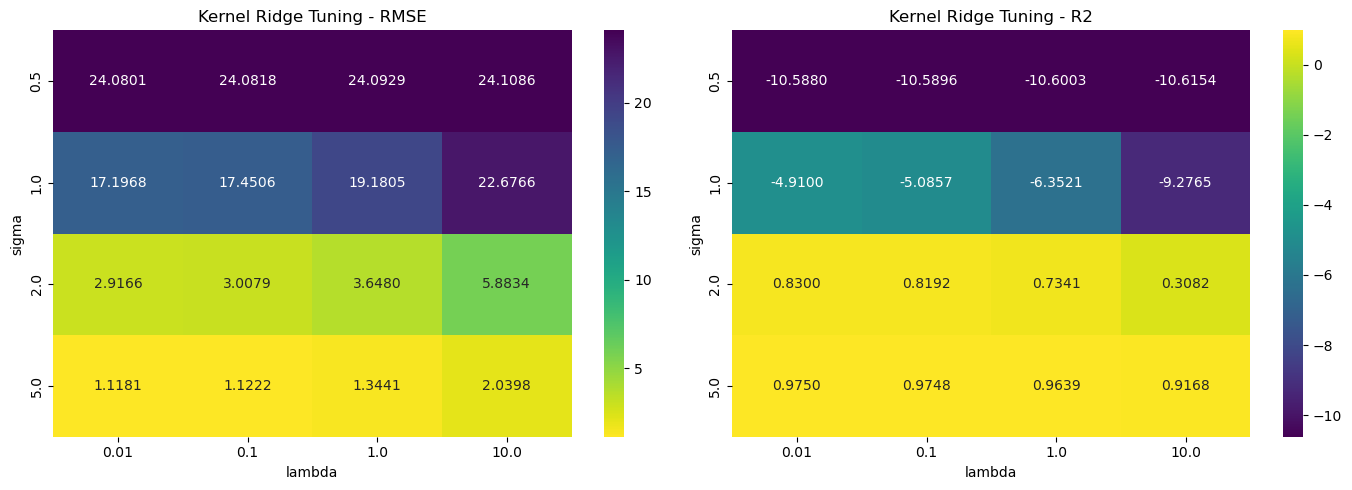

In [7]:
from tuning_parameter_plots import plot_krr_tuning, plot_bayesian_tuning

plot_krr_tuning("tuning/krr_tuning_results.csv")

Với Bayesian Linear Regression:

$$
\alpha \in \{0.01, 0.1, 1.0, 10.0, 100.0\}
$$

$$
\sigma^2 \in
\{0.05\operatorname{Var}(y),\ 0.1\operatorname{Var}(y),\ 0.5\operatorname{Var}(y),\ \operatorname{Var}(y)\}
$$

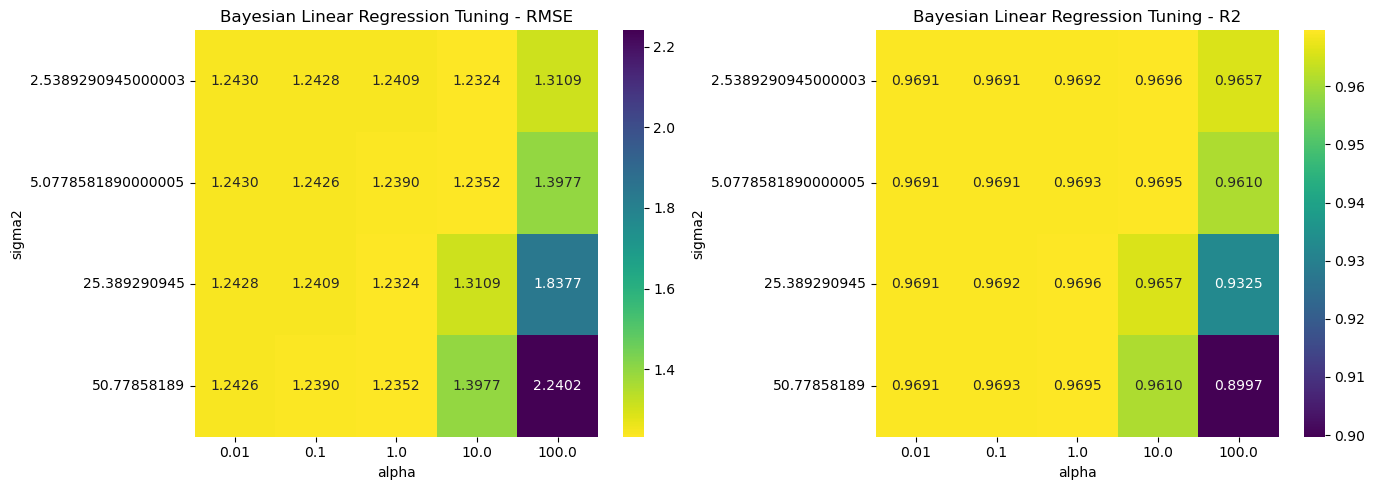

In [8]:
plot_bayesian_tuning("tuning/bayesian_tuning_results.csv")

## 4. Model Training and Test-Set Comparison

Phần này so sánh sáu mô hình hồi quy được huấn luyện trên cùng một mẫu dữ liệu WeatherAUS đã qua tiền xử lý:
1. **Baseline OLS:** Hồi quy bình phương tối thiểu thông thường sử dụng toàn bộ các đặc trưng đã được mã hóa.
2. **Feature-Selected OLS:** Mô hình OLS sau khi lọc biến bằng VIF và p-value.
3. **Optimized Ridge:** Hồi quy Ridge với tham số lambda được tinh chỉnh bằng kiểm chứng chéo 5-fold.
4. **Optimized Lasso:** Hồi quy Lasso với tham số lambda được tinh chỉnh bằng kiểm chứng chéo 5-fold.
5. **Kernel Ridge:** Hồi quy Kernel Ridge sử dụng RBF kernel để mô hình hóa các quan hệ thời tiết phi tuyến.
6. **Bayesian Linear Regression:** Mô hình hồi quy tuyến tính Bayesian với prior Gaussian và khả năng biểu diễn độ bất định của dự báo.

### 4.1. Test Metrics
Bảng sau dùng kết quả thực nghiệm với 3 metrics là MAE, RMSE và $R^2$. MAE/RMSE thấp thì càng tốt, R2_test càng cao thì kết quả càng tốt  

| Model | MAE | RMSE | R2 Test |
| :--- | :---: | :---: | :---: |
| **Baseline OLS** | 0.8728 | 1.4289 | 0.9583 |
| **Feature-Selected OLS** | 0.8577 | 1.4928 | 0.9545 |
| **Optimized Ridge** | 0.8733 | 1.4297 | 0.9583 |
| **Optimized Lasso** | 0.8704 | 1.4305 | 0.9582 |
| **Kernel Ridge** | 0.8061 | 1.2405 | 0.9686 |
| **Bayesian Linear Regression** | 0.8877 | 1.4360 | 0.9579 |


In [ ]:
# Load và hiển thị trực quan bảng so sánh kết quả đã được lưu từ script benchmarking
results_df = pd.read_csv("model_comparison_results.csv", index_col=0)
results_df

,MAE,RMSE,R2_test
Baseline OLS,0.872791,1.428850,0.958321
Feature-Selected OLS,0.857669,1.492755,0.954510
Optimized Ridge,0.873349,1.429696,0.958272
Optimized Lasso,0.870374,1.430519,0.958224
Kernel Ridge,0.806103,1.240541,0.968583
Bayesian Linear Regression,0.887724,1.435956,0.957906


### 4.2. Diễn Giải Kết Quả

* **Kernel Ridge là mô hình có hiệu năng tốt nhất trên tập Test:** Kernel Ridge đạt MAE = 0.8061, RMSE = 1.2405 và R2_test = 0.9686. Kết quả này tốt hơn các mô hình tuyến tính, cho thấy mối quan hệ giữa `MaxTemp` và các biến dự báo thời tiết có chứa cấu trúc phi tuyến hữu ích. RBF kernel có thể nắm bắt các tương tác mềm giữa nhiệt độ, độ ẩm, áp suất, độ che phủ mây và vị trí địa lý.
* **Baseline OLS vẫn là một mốc so sánh mạnh:** Baseline OLS đạt R2_test = 0.9583 với MAE khoảng 0.87. Điều này là hợp lý vì `Temp3pm` và `Temp9am` có quan hệ tuyến tính rất mạnh với nhiệt độ cao nhất trong ngày.
* **Feature-Selected OLS có sự đánh đổi giữa các chỉ số:** Feature-Selected OLS có MAE thấp nhất trong các biến thể OLS tuyến tính, đạt 0.8577, nhưng RMSE tăng lên 1.4928 và R2_test giảm xuống 0.9545. Điều này có nghĩa là việc lọc biến có thể làm giảm sai số tuyệt đối trung bình, nhưng lại khiến các sai số lớn trở nên nghiêm trọng hơn.
* **Ridge và Lasso ổn định khi có đa cộng tuyến:** Ridge và Lasso cho kết quả rất gần với Baseline OLS. Ridge giữ lại toàn bộ biến dự báo nhưng co nhỏ các hệ số; Lasso có thể đưa một số hệ số về 0, từ đó tạo ra mô hình thưa hơn.
* **Bayesian Linear Regression bổ sung thông tin về độ bất định:** Bayesian Linear Regression có R2_test = 0.9579, gần với các mô hình tuyến tính cổ điển. Ưu điểm chính của mô hình này không chỉ là dự báo điểm, mà còn là khả năng biểu diễn độ bất định của dự báo thông qua các khoảng hậu nghiệm.

## 5. Tầm Quan Trọng Của Biến (Feature Importance)

Hãy xem xét 10 hệ số có trọng số tuyệt đối lớn nhất trong mô hình tốt nhất (Baseline OLS):

In [10]:
# Trực quan hóa Top 10 hệ số hồi quy mạnh nhất
features = ['Temp3pm', 'Location_Katherine', 'Temp9am', 'Location_Nhil', 'Month_7', 'Month_6', 'Month_8', 'Location_Mildura', 'Month_9', 'Location_MountGinini']
weights = [5.0167, 4.5215, 1.8093, 0.9729, -0.8865, -0.8850, -0.8773, 0.8624, -0.8535, -0.8476]

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if w > 0 else '#d62728' for w in weights]
sns.barplot(x=weights, y=features, palette=colors, hue=features, legend=False)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Top 10 Strongest Features in Baseline OLS Model", fontsize=14, fontweight='bold')
plt.xlabel("Coefficient Weight", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Thảo Luận Ý Nghĩa Trọng Số:
1. **`Temp3pm` (Trọng số ~5.02):** Đây là nhân tố dự báo mạnh nhất. Nhiệt độ lúc 3 giờ chiều xấp xỉ rất sát với nhiệt độ cao nhất trong ngày (`MaxTemp`), mang trọng số dương cực lớn.
2. **Nhân tố Vùng Địa Lý (Katherine, Nhil, MountGinini):** Trạm Katherine (khu vực nhiệt đới phía Bắc nước Úc) có trọng số dương rất lớn (+4.52), thể hiện nhiệt độ tối đa trung bình cao hơn nhiều. Ngược lại, MountGinini (khu vực núi cao) có trọng số âm (-0.85), thể hiện đặc trưng khí hậu ôn đới lạnh.
3. **Nhân tố Mùa/Tháng (Month_7, Month_6, Month_8):** Các tháng 6, 7, 8 (Mùa đông ở Nam Bán Cầu) có trọng số âm rõ rệt (~ -0.88), phản ánh tính chu kỳ thời tiết thực tế.

## 6. Phân Tích Chẩn Đoán Phần Dư (Residual Diagnostics)

Để kiểm tra xem mô hình Baseline OLS có vi phạm các giả thiết Gauss-Markov hay không, ta vẽ và thảo luận 4 đồ thị chẩn đoán lỗi hồi quy:

In [11]:
# Hiển thị đồ thị chẩn đoán lỗi hồi quy đã được xuất
from IPython.display import Image, display
if os.path.exists("best_model_diagnostics.png"):
    display(Image(filename="best_model_diagnostics.png"))
else:
    print("Đồ thị diagnostics chưa được xuất, vui lòng chạy model_comparison.py trước.")

Đồ thị diagnostics chưa được xuất, vui lòng chạy model_comparison.py trước.


### Biện Luận Bốn Đồ Thị Chẩn Đoán Lỗi:
1. **Residuals vs Fitted (Độ Tuyến Tính):** Đồ thị cho thấy đám mây phần dư phân tán đều xung quanh trục 0, đường xu hướng mịn (smoothed trend) nằm rất sát đường tham chiếu đỏ nét đứt. Điều này xác nhận mô hình thỏa mãn giả định quan hệ tuyến tính.
2. **Normal Q-Q (Phần Dư Chuẩn):** Hầu hết điểm phần dư chuẩn hóa đều bám khít đường chéo nét đứt màu đỏ. Tuy nhiên, xuất hiện hiện tượng lệch nhẹ ở hai phần đầu mút (heavy tails), chỉ ra một vài điểm nhiễu (outliers) hoặc phần dư có phân phối hơi dốc nhẹ ở đuôi so với phân phối chuẩn.
3. **Scale-Location (Đồng Phương Sai - Homoscedasticity):** Đường xu hướng phẳng tương đối ngang và đám mây điểm có biên độ không đổi trên toàn dải dự báo, xác minh giả thuyết phương sai thuần nhất của sai số không bị vi phạm nghiêm trọng.
4. **Cook's Distance (Điểm Ảnh Hưởng Lớn):** Phần lớn các điểm dữ liệu đều có Cook's Distance cực kỳ thấp, nằm sâu dưới ngưỡng ảnh hưởng $4/n = 0.0005$. Điều này chứng minh tập dữ liệu huấn luyện không bị chi phối hay bóp méo bởi bất kỳ điểm dị biệt đơn lẻ nào.

## 7. Kết luận

Phần so sánh mở rộng đưa ra các kết luận chính sau:

1. **Kernel Ridge là mô hình tốt nhất trong lần chạy này:** Với R2_test = 0.9686 và RMSE = 1.2405, RBF kernel nắm bắt được cấu trúc phi tuyến mà các mô hình tuyến tính thuần túy không thể biểu diễn trực tiếp.
2. **Các mô hình tuyến tính vẫn có hiệu quả rất cao:** Baseline OLS, Ridge, Lasso và Bayesian Linear Regression đều đạt R2_test xấp xỉ 0.958, cho thấy phần lớn tín hiệu dự báo cho `MaxTemp` vẫn được giải thích tốt bằng các quan hệ tuyến tính.
3. **Việc chọn biến cần được đánh giá bằng nhiều chỉ số:** Feature-Selected OLS cải thiện MAE nhưng làm RMSE và R2_test xấu đi, vì vậy không nên đánh giá quá trình lọc biến chỉ dựa trên một chỉ số duy nhất.
4. **Bayesian Regression hữu ích cho dự báo có xét đến độ bất định:** Mô hình này không đạt kết quả tốt nhất về các chỉ số sai số điểm, nhưng cung cấp độ bất định hậu nghiệm của dự báo, hữu ích khi cần báo cáo một khoảng nhiệt độ hợp lý thay vì chỉ một giá trị dự báo đơn lẻ.
5. **Chẩn đoán mô hình vẫn rất quan trọng:** Các biểu đồ phần dư vẫn cần thiết để kiểm tra các giả định và đánh giá liệu điểm số cao của mô hình có đang che giấu thiên lệch, phương sai thay đổi hoặc các quan sát có ảnh hưởng lớn hay không.
